#M507 Methods of Prediction - Reassessment Project
#Title: Fashion-MNIST classification with convolutional neural networks

Student name: Yashas Mekanda Somaiah  
Date: 01.07.2026  
Dataset: https://www.kaggle.com/datasets/zalando-research/fashionmnist$0

Github:

1. Introduction

In this project, I developed a complete machine learning pipeline for classifying images of clothing items. I used a Convolutional Neural Network because I learned in class that CNN are very good at understanding images by detecting edges, shapes, and patterns.

The main goal of this project is to solve a real business problem in the fashion industry using deep learning. I will explain every step clearly from understanding the problem to training the model and evaluating the results.

2. Business Problem

During my research, I realized that big online fashion stores like Amazon or Zalando get thousands of new product photos every single day. Right now, employees have to look at each image and manually choose the correct category like T-shirt, Shirt, Sneaker, etc.

This manual work has many problems:
- It takes a lot of time and costs a lot of money, humans can make mistakes especially when items look similar.
- New products take longer to appear on the website and customers get bad search results and become very unhappy.
- The company loses money because of wrong recommendations and high return rates.

This is a big challenge for the company, and solving it with AI can save time and money while making customers happier.

 3. Business Solution

To solve this problem, I built an automated system that can look at a clothing image and correctly predict which category it belongs to.

I used a Convolutional Neural Network because it can automatically learn important features from images. Once trained, this model can instantly classify new images.

This solution will help the company:
- Save a lot of time and reduce labor costs
- Add new products to the website much faster
- Improve search accuracy
- Give better product recommendations to customers
- Reduce the number of returns

In the future, this model could be integrated directly into their product upload system.

#Libraries

In [31]:

import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


#Loading the dataset

In [32]:

train_df = pd.read_csv('/content/fashion-mnist_train.csv')
test_df = pd.read_csv('/content/fashion-mnist_test.csv')

x_train_full = train_df.drop('label', axis=1).values.reshape(-1, 28, 28)
y_train_full = train_df['label'].values

x_test = test_df.drop('label', axis=1).values.reshape(-1, 28, 28)
y_test = test_df['label'].values

x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Exploring the Dataset


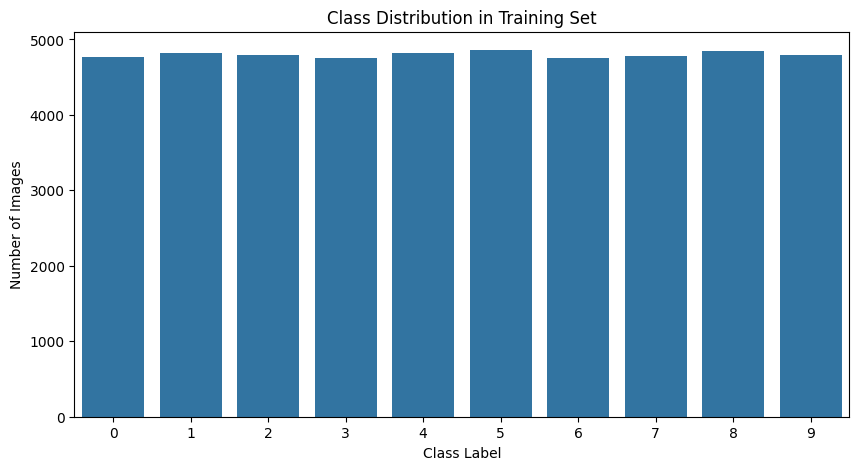

In [35]:

print("Exploring the Dataset")

plt.figure(figsize=(10,5))
sns.countplot(x=y_train)
plt.title("Class Distribution in Training Set")
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.show()


The dataset is now perfectly balanced so it is now good for training.

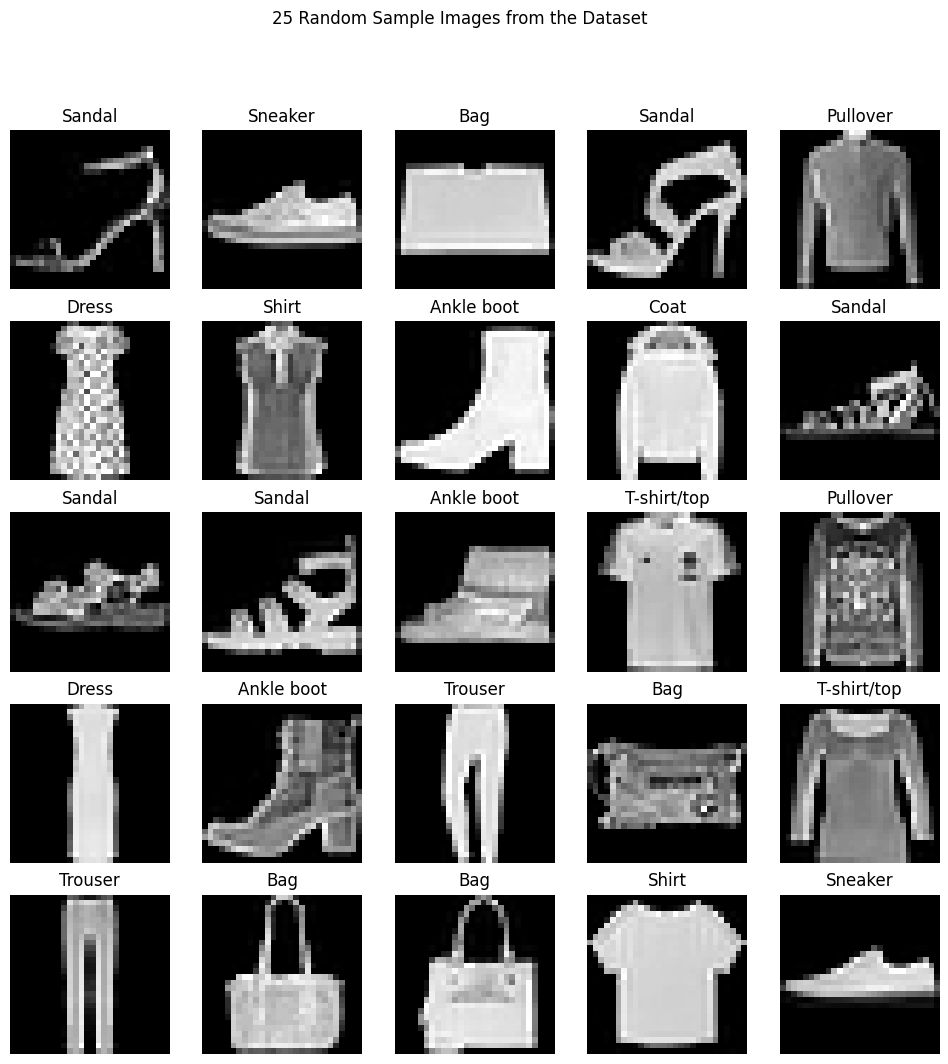

In [36]:

plt.figure(figsize=(12,12))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("25 Random Sample Images from the Dataset")
plt.show()

#Distribution of pixels

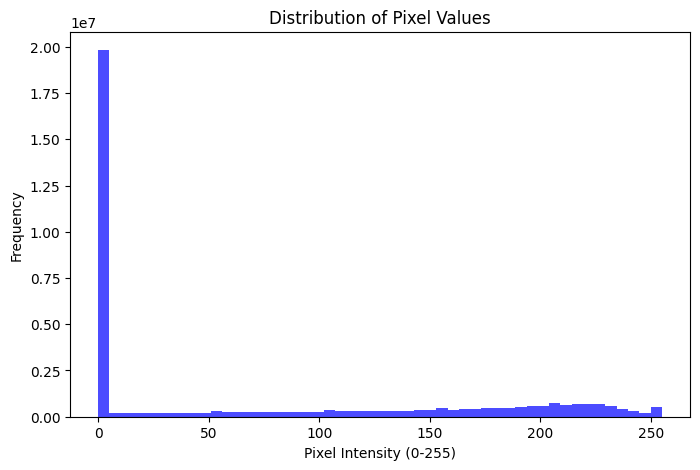

In [23]:
plt.figure(figsize=(8,5))
plt.hist(x_train.flatten(), bins=50, color='blue', alpha=0.7)
plt.title("Distribution of Pixel Values")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.show()

#Data preprocessing

In [24]:

x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_val = np.expand_dims(x_val, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Data has been normalized between 0 and 1 and reshaped for CNN.")

Data has been normalized between 0 and 1 and reshaped for CNN.


The data now has been normalized between 0 and 1 and now is good to train for the CNN model.

#Building the CNN model

In [25]:

def create_cnn_model():
    model = keras.Sequential([
        keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1), padding='same'),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2,2)),

        keras.layers.Flatten(),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = create_cnn_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993,930 (3.79 MB)

 Trainable params: 993,930 (3.79 MB)

 Non-trainable params: 0 (0.00 B)

#Training the model.

In [26]:
history = model.fit(x_train, y_train,
                    epochs=20,
                    batch_size=128,
                    validation_data=(x_val, y_val),
                    verbose=1)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.7604 - loss: 0.6503 - val_accuracy: 0.8601 - val_loss: 0.3707
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8691 - loss: 0.3639 - val_accuracy: 0.8952 - val_loss: 0.2873
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8945 - loss: 0.2978 - val_accuracy: 0.9078 - val_loss: 0.2623
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9071 - loss: 0.2617 - val_accuracy: 0.9082 - val_loss: 0.2500
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9156 - loss: 0.2335 - val_accuracy: 0.9194 - val_loss: 0.2246
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9262 - loss: 0.2054 - val_accuracy: 0.9224 - val_loss: 0.2200
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9323 - loss: 0.1859 - val_accuracy: 0.9193 - val_loss: 0.2266
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9402 - loss: 0.1679 - val_acc

#Training performance visualisation

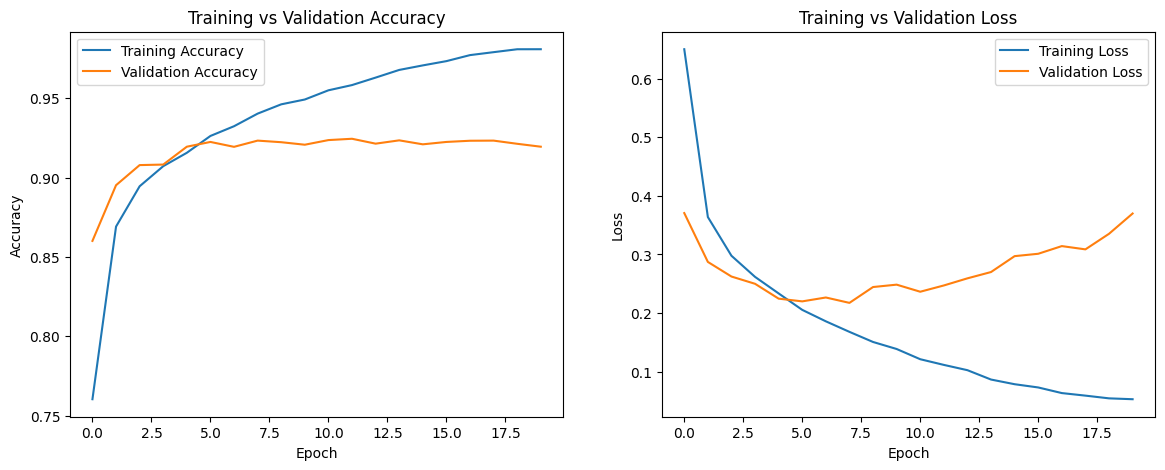

In [27]:

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

#Performance after the training

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


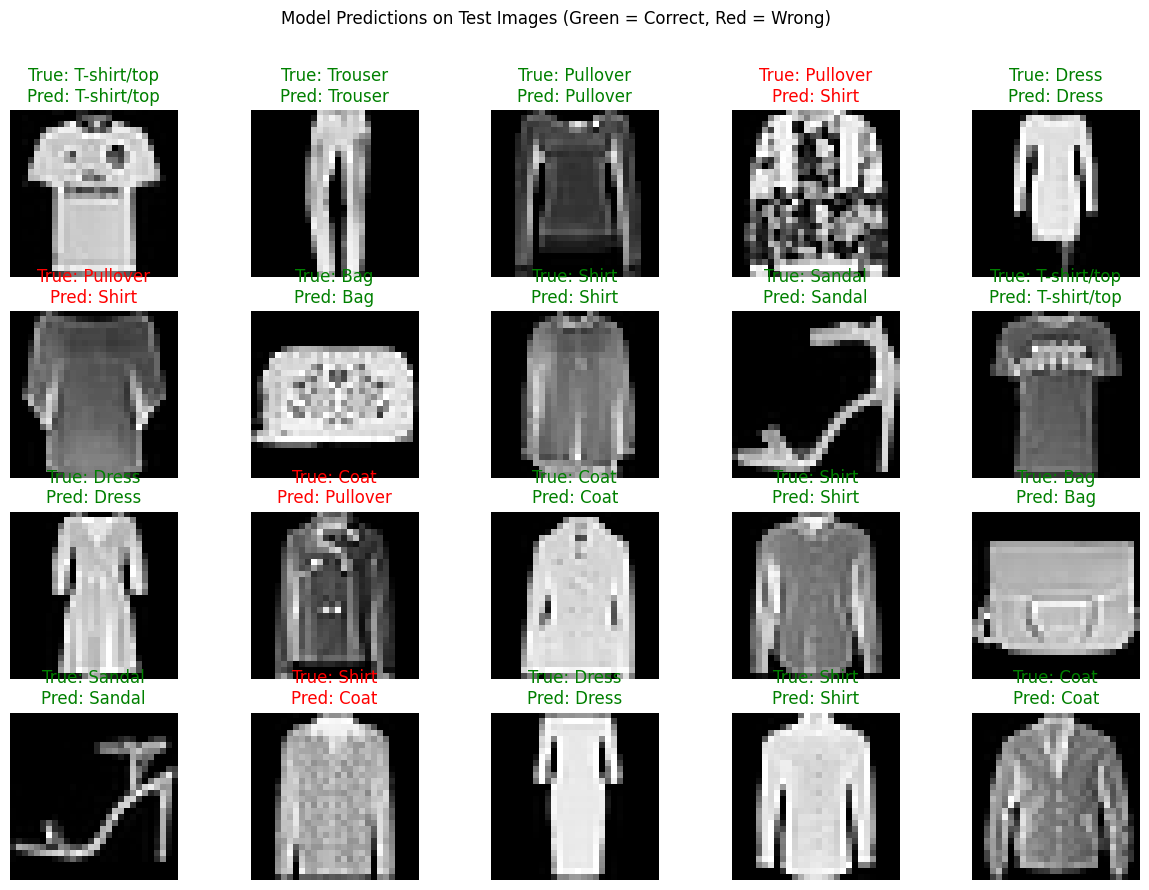

In [28]:

y_pred = np.argmax(model.predict(x_test), axis=1)

plt.figure(figsize=(15, 10))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    true_label = class_names[y_test[i]]
    pred_label = class_names[y_pred[i]]
    color = 'green' if y_test[i] == y_pred[i] else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')
plt.suptitle("Model Predictions on Test Images (Green = Correct, Red = Wrong)")
plt.show()

#Confusion matrix

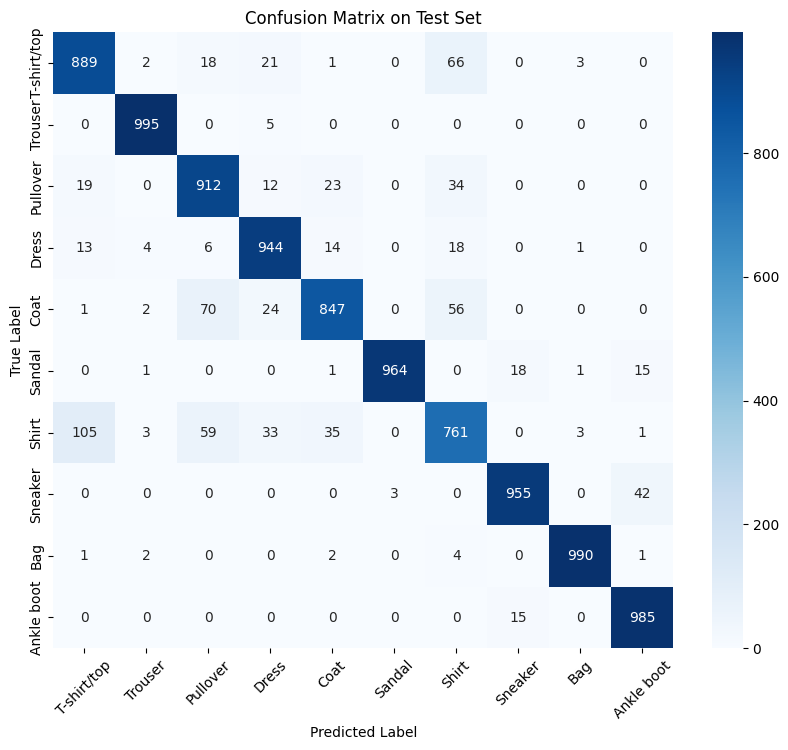

In [29]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.show()

#Final result and accuracy.

In [30]:

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Final Test Accuracy: 0.9242 (92.42%)

Detailed Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.86      0.91      0.88      1000
       Dress       0.91      0.94      0.93      1000
        Coat       0.92      0.85      0.88      1000
      Sandal       1.00      0.96      0.98      1000
       Shirt       0.81      0.76      0.78      1000
     Sneaker       0.97      0.95      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.94      0.98      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



Discussion

In this project i learned how the CNN model works and how to build a full machine learning pipeline. The model which i built performed quite well with around 92.42% accuracy, which I am happy with.

Strengths: The model can now immediatly recognize different types of clothing. The training process was stable and validation accuracy was good.

Limitations:
- The images are small (28x28) and only grayscale. Real product photos are usually bigger and in color. Some classes like shirt and coat are often confused because they look similar.
- I did not use advanced techniques like data augmentation in the final model.

Recommendations for the Business:
- Use this model to automatically tag new products.
- For uncertain predictions which is low confidence, send them to a human for review.
- In the future, I recommend using transfer learning with bigger colored images.

 Summary:
This project successfully demonstrates how deep learning can solve a practical business problem. I applied all the concepts I learned in the module: data exploration, preprocessing, model building, evaluation, and critical thinking about results.